数据前5行：
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  55.0        0                       748         0                 45   
1  65.0        0                        56         0                 25   
2  45.0        0                       582         1                 38   
3  60.0        1                       754         1                 40   
4  95.0        1                       582         0                 30   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    0  263358.03               1.3           137    1   
1                    0  305000.00               5.0           130    1   
2                    0  319000.00               0.9           140    0   
3                    1  328000.00               1.2           126    1   
4                    0  461000.00               2.0           132    1   

   smoking  time  DEATH_EVENT  
0        1    88            0  
1        0   207            0  
2

/var/folders/31/49_vvxf17s12xg22h77mxwkm0000gn/T/ipykernel_40109/1578007972.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


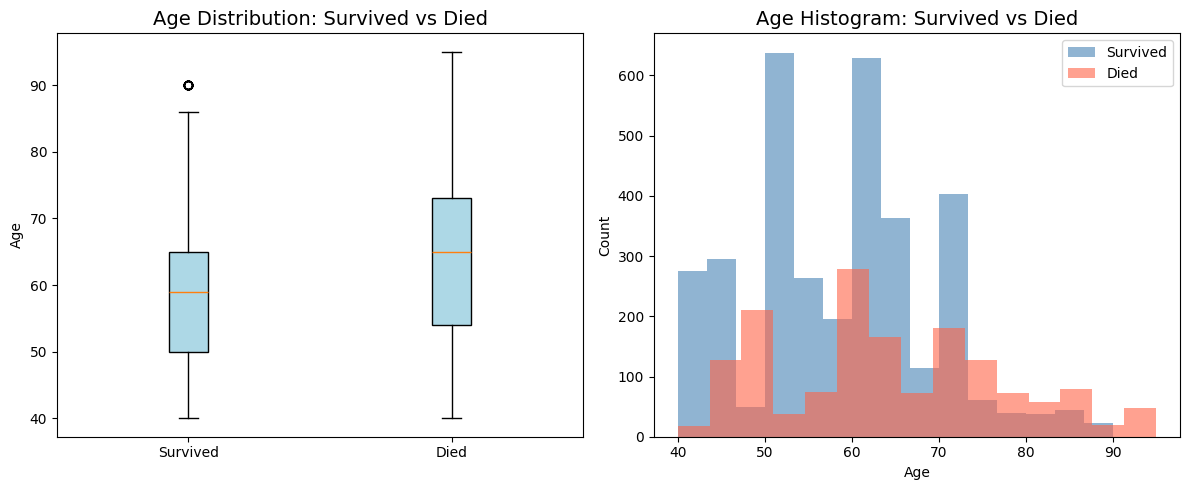

/var/folders/31/49_vvxf17s12xg22h77mxwkm0000gn/T/ipykernel_40109/1578007972.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


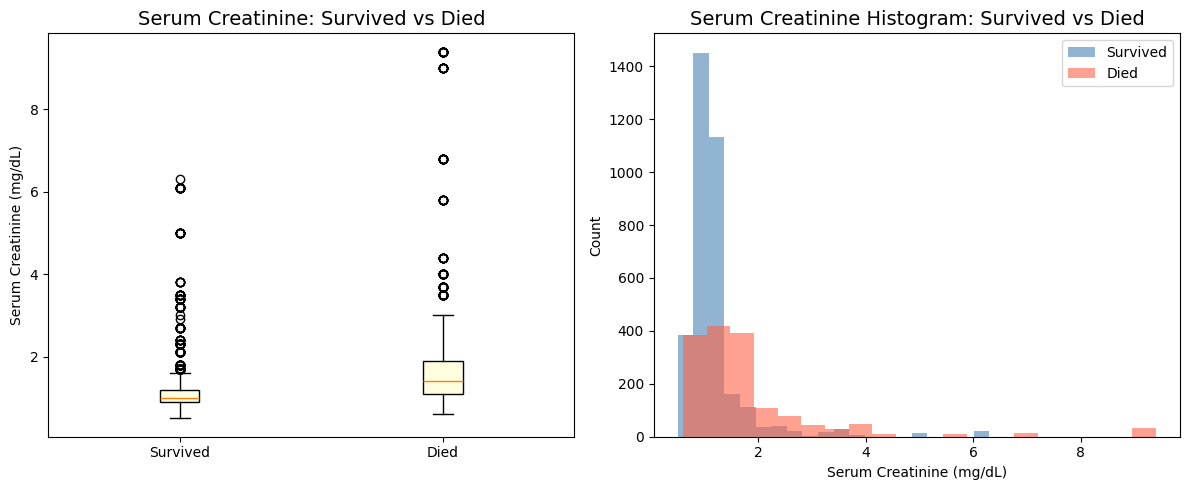


===== 存活 vs 死亡：均值对比 =====
年龄    - 存活: 58.3  |  死亡: 64.6
血清肌酐 - 存活: 1.16  |  死亡: 1.83


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print("First 5 rows of the data:")
print(df.head())
print()
print("Basic information of the data:")
print(df.describe())

survived = df[df["DEATH_EVENT"] == 0]  
died = df[df["DEATH_EVENT"] == 1]     

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].boxplot(
    [survived["age"], died["age"]],
    labels=["Survived", "Died"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
)
axes[0].set_title("Age Distribution: Survived vs Died", fontsize=14)
axes[0].set_ylabel("Age")


axes[1].hist(survived["age"], bins=15, alpha=0.6, label="Survived", color="steelblue")
axes[1].hist(died["age"], bins=15, alpha=0.6, label="Died", color="tomato")
axes[1].set_title("Age Histogram: Survived vs Died", fontsize=14)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("age_vs_death.png", dpi=150)  
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(
    [survived["serum_creatinine"], died["serum_creatinine"]],
    labels=["Survived", "Died"],
    patch_artist=True,
    boxprops=dict(facecolor="lightyellow"),
)
axes[0].set_title("Serum Creatinine: Survived vs Died", fontsize=14)
axes[0].set_ylabel("Serum Creatinine (mg/dL)")


axes[1].hist(survived["serum_creatinine"], bins=20, alpha=0.6, label="Survived", color="steelblue")
axes[1].hist(died["serum_creatinine"], bins=20, alpha=0.6, label="Died", color="tomato")
axes[1].set_title("Serum Creatinine Histogram: Survived vs Died", fontsize=14)
axes[1].set_xlabel("Serum Creatinine (mg/dL)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("serum_creatinine_vs_death.png", dpi=150) 
plt.show()


print("\n===== Survived vs Deceased: Mean Comparison =====")
print(f"Age            - Survived: {survived['age'].mean():.1f}  |  Deceased: {died['age'].mean():.1f}")
print(f"Serum Creatinine - Survived: {survived['serum_creatinine'].mean():.2f}  |  Deceased: {died['serum_creatinine'].mean():.2f}")